In [197]:
#carga los datos desde el csv a pandas
import pandas as pd

def corregir_overflow(valor):
    if valor > 60000:
        return valor - 65536
    return valor


df = pd.read_csv(
    'medicion_rows.csv',
    parse_dates=['created_at'],
    dtype={
        'frecuencia': 'int64',
        'bomba': 'bool',
        'caudal': 'int64',
        'presion': 'int64',
        'nivel': 'int64'
    }
)

# corregir el overflow en las columnas de presión y caudal
df['presion'] = df['presion'].apply(corregir_overflow)
df['caudal'] = df['caudal'].apply(corregir_overflow)

# escalamiento de los datos
df['nivel'] = df['nivel'] / 10
df['presion'] = df['presion'] / 1
df['caudal'] = df['caudal'] / 100
df['frecuencia'] = df['frecuencia'] / 10
df['bomba'] = df['bomba'].astype(int)
df['created_at'] = pd.to_datetime(df['created_at'])

# Convertir a galones
# diamentro del tanque = 120 cm -> radio = 60 cm
# Área de la sección transversal del tanque = π * r^2 = π * (60 cm)^2 ≈ 11309.73 cm²
# Volumen = Área * altura -> volumen en cm³, para convertir a galones: 1 galón ≈ 3785.41 cm³
df['volumen_real'] = df['nivel']/10 * 11309.73 / 3785.41

print(df.dtypes)
print(df.head())

created_at      datetime64[us, UTC]
frecuencia                  float64
bomba                         int64
caudal                      float64
presion                     float64
nivel                       float64
volumen_real                float64
dtype: object
                        created_at  frecuencia  bomba  caudal  presion  nivel  \
0 2026-06-04 13:46:21.438931+00:00        40.0      1    0.07   3451.0  804.6   
1 2026-06-04 13:46:26.448370+00:00        40.0      1    0.07   3354.0  804.6   
2 2026-06-04 13:46:31.460547+00:00        40.0      1    0.72   3371.0  804.8   
3 2026-06-04 13:46:36.469208+00:00        40.0      1   21.23   3445.0  804.6   
4 2026-06-04 13:46:41.437713+00:00        40.0      1   69.12   3496.0  804.8   

   volumen_real  
0    240.391629  
1    240.391629  
2    240.451383  
3    240.391629  
4    240.451383  


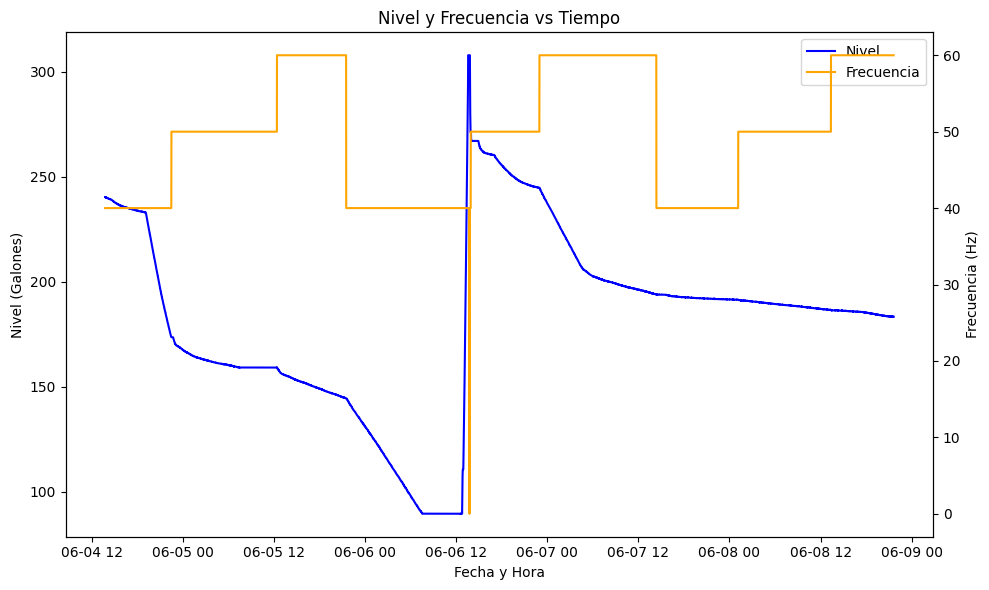

In [198]:
# variacion de nivel con respecto al tiempo
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje Y izquierdo
ax1.plot(df['created_at'], df['volumen_real'], label='Nivel', color='blue')
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Nivel (Galones)')
ax1.tick_params(axis='y')

# Eje Y derecho
ax2 = ax1.twinx()
ax2.plot(df['created_at'], df['frecuencia'], label='Frecuencia', color='orange')
ax2.set_ylabel('Frecuencia (Hz)')
ax2.tick_params(axis='y')

# Título
plt.title('Nivel y Frecuencia vs Tiempo')

# Combinar leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


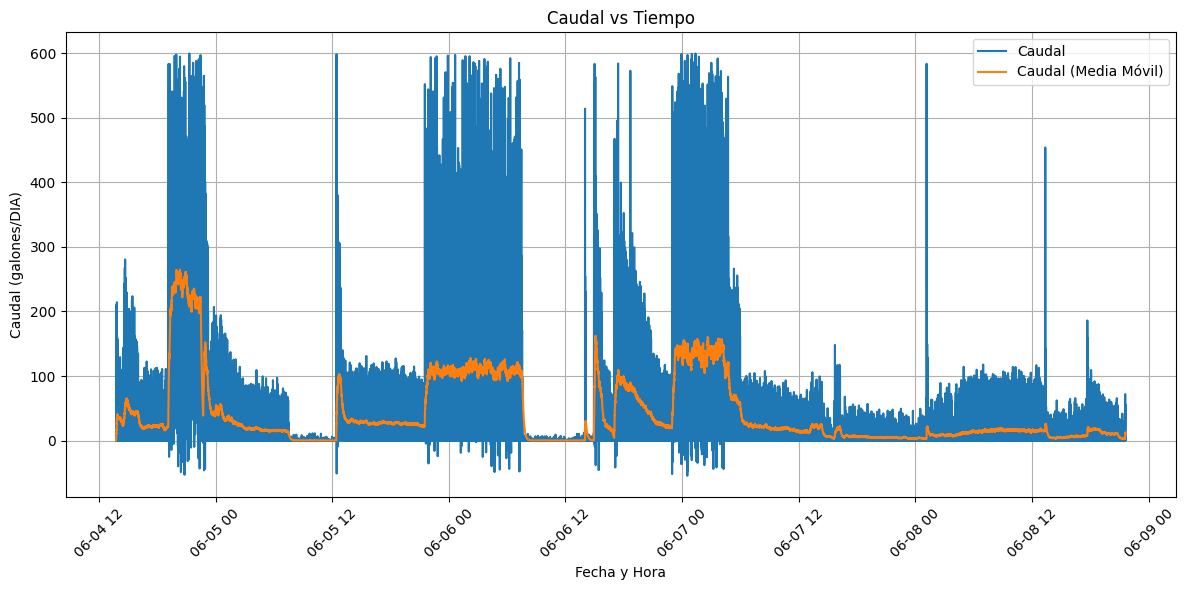

In [199]:
# GRAFICA DEL CAUDAL CON RESPECTO AL TIEMPO
df['caudal_FIT'] = ( df['caudal'].ewm(span=100, adjust=False).mean() )
plt.figure(figsize=(12,6))
plt.plot(df['created_at'], df['caudal'], label='Caudal')
plt.plot(df['created_at'], df['caudal_FIT'], label='Caudal (Media Móvil)')
plt.title('Caudal vs Tiempo')
plt.xlabel('Fecha y Hora')
plt.ylabel('Caudal (galones/DIA)')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

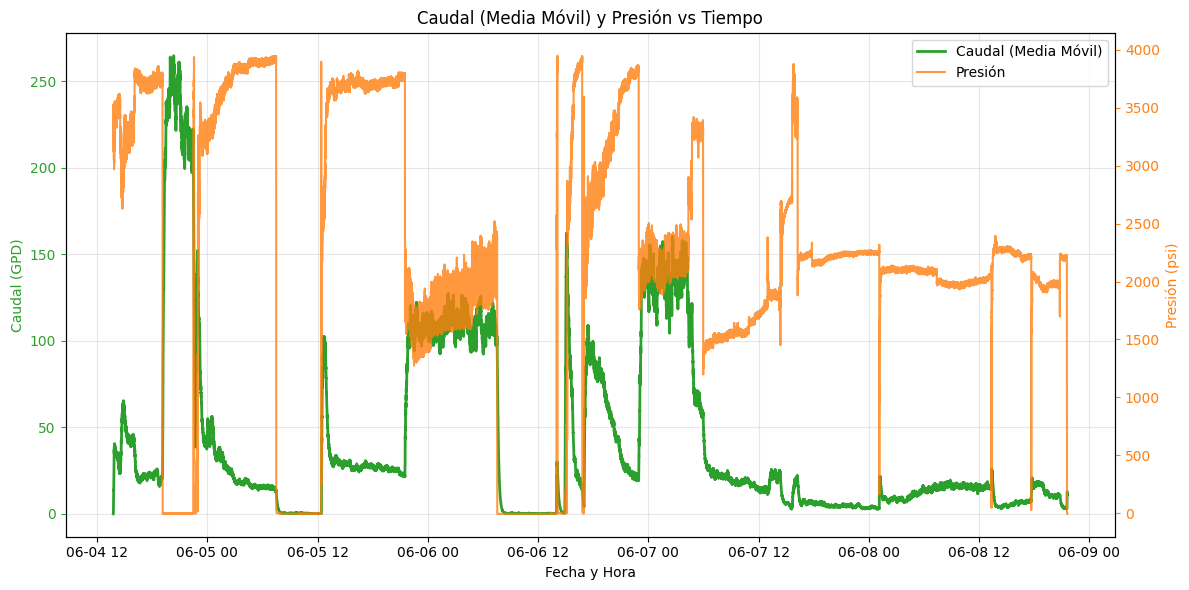

In [200]:
plt.figure(figsize=(12,6))

ax1 = plt.gca()

# Caudal
ax1.plot(
    df['created_at'],
    df['caudal_FIT'],
    label='Caudal (Media Móvil)',
    color='tab:green',
    linewidth=2
)

ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Caudal (GPD)', color='tab:green')
ax1.tick_params(axis='y', colors='tab:green')

# Presión
ax2 = ax1.twinx()

ax2.plot(
    df['created_at'],
    df['presion'],
    label='Presión',
    color='tab:orange',
    linewidth=1.5,
    alpha=0.8
)

ax2.set_ylabel('Presión (psi)', color='tab:orange')
ax2.tick_params(axis='y', colors='tab:orange')

plt.title('Caudal (Media Móvil) y Presión vs Tiempo')

# Cuadrícula más suave
ax1.grid(True, alpha=0.3)

# Leyenda conjunta
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

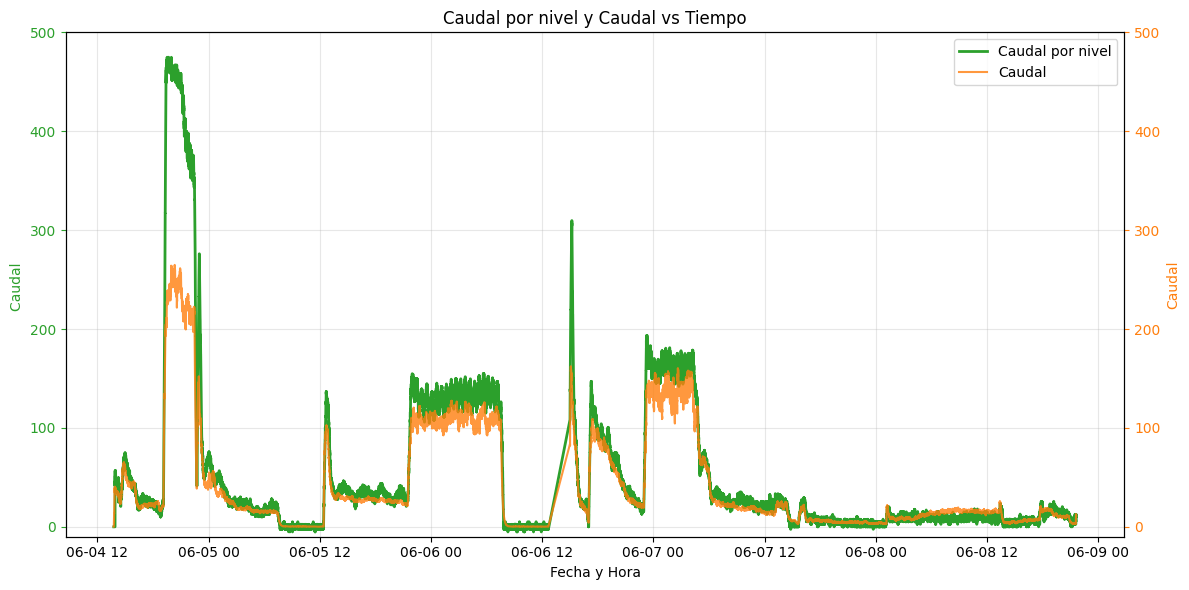

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


(-10.0, 10.0)

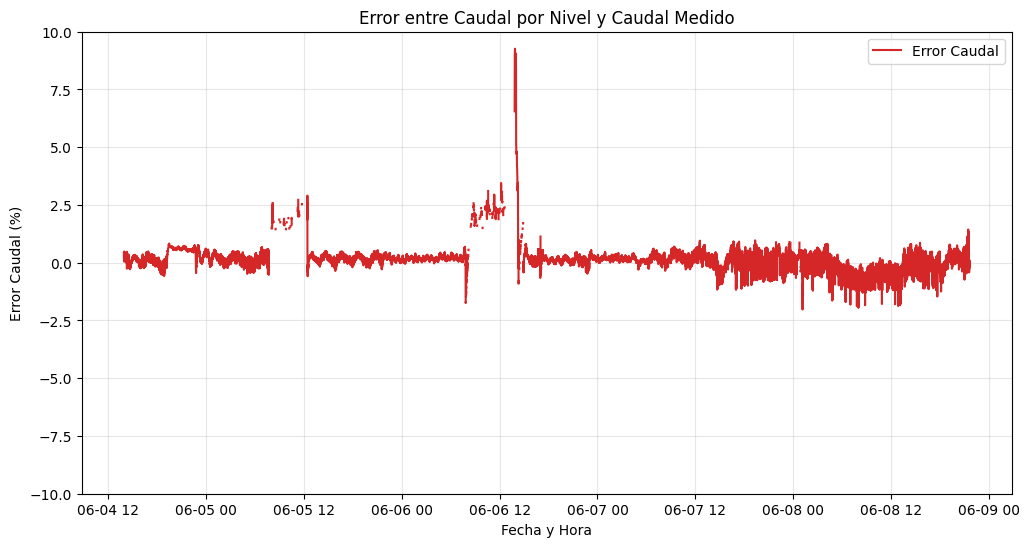

In [201]:
import numpy as np
# caudal a partir del nivel
df['caudal_nivel'] = -( df['volumen_real'].diff(periods=100) )/ ( df['created_at'].diff(periods=100).dt.total_seconds() / 86400 )
df['caudal_nivel'] = df['caudal_nivel'].fillna(0)
#gracfica solo 2 dias de caudal a partir del nivel
#df_sin_refill = df
df_sin_refill = df[(df['created_at'] < "2026-06-06 12:40:00") | (df['created_at'] > "2026-06-06 15:00:00")]
#df_sin_refill = df[(df['created_at'] < "2026-06-06 12:40:00")]
plt.figure(figsize=(12,6))
ax1 = plt.gca()
ax1.plot(df_sin_refill['created_at'], df_sin_refill['caudal_nivel'], label='Caudal por nivel', color='tab:green', linewidth=2)
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Caudal ', color='tab:green')
ax1.tick_params(axis='y', colors='tab:green')
ax1.set_ylim(-10, 500)

ax2 = ax1.twinx()
ax2.plot(df_sin_refill['created_at'],df_sin_refill['caudal_FIT'], label='Caudal', color='tab:orange', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Caudal', color='tab:orange')
ax2.tick_params(axis='y', colors='tab:orange')
ax2.set_ylim(-10, 500)
plt.title('Caudal por nivel y Caudal vs Tiempo')
ax1.grid(True, alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# grafica del error entre el caudal por nivel y el caudal medido

df['error_caudal'] = np.log(df['caudal_nivel']) - np.log(df['caudal_FIT'])
plt.figure(figsize=(12,6))
plt.plot(df['created_at'], df['error_caudal'], label='Error Caudal', color='tab:red', linewidth=1.5)
plt.xlabel('Fecha y Hora')
plt.ylabel('Error Caudal (%)')
plt.title('Error entre Caudal por Nivel y Caudal Medido')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-10, 10)

In [202]:
print(df['caudal_nivel'])


0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
           ...    
36922    12.527026
36923    12.527095
36924    10.021449
36925    12.525615
36926    10.022335
Name: caudal_nivel, Length: 36927, dtype: float64


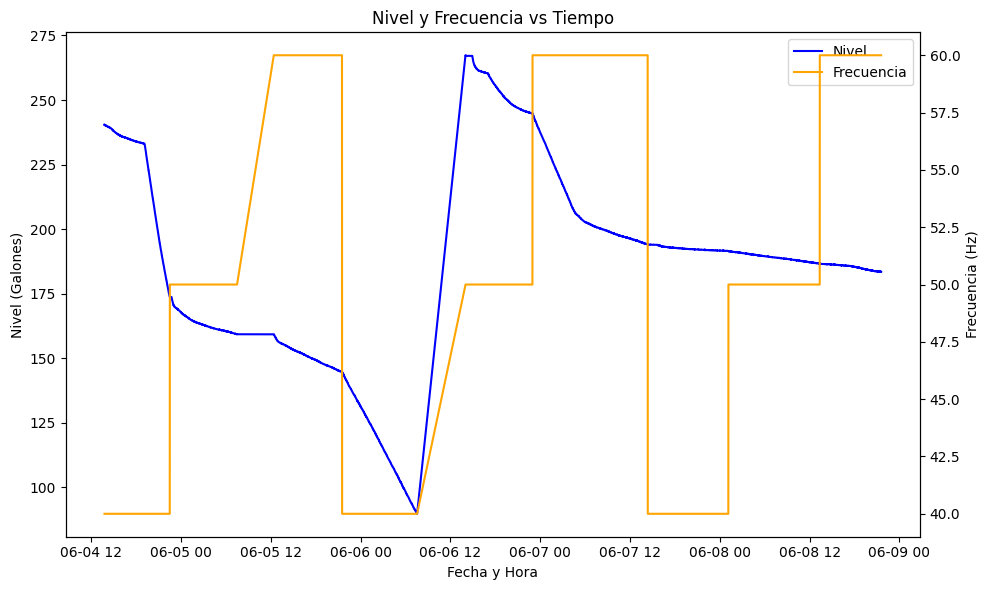

In [203]:
# variacion de nivel con respecto al tiempo

df_on = df[df['bomba'] == 1]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje Y izquierdo
ax1.plot(df_on['created_at'], df_on['volumen_real'], label='Nivel', color='blue')
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Nivel (Galones)')
ax1.tick_params(axis='y')

# Eje Y derecho
ax2 = ax1.twinx()
ax2.plot(df_on['created_at'], df_on['frecuencia'], label='Frecuencia', color='orange')
ax2.set_ylabel('Frecuencia (Hz)')
ax2.tick_params(axis='y')

# Título
plt.title('Nivel y Frecuencia vs Tiempo')

# Combinar leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
